In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import urllib.parse
import warnings
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SAWarning
from tqdm.auto import tqdm

from IPython import display

import random

import os
import joblib

D:\dev\conda_envs\lmsAI\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [161]:
# ==========================================
# 1. MSSQL 데이터베이스 연결 및 데이터 로드
# ==========================================

warnings.filterwarnings("ignore", category=SAWarning)

COL = 'F10_06'

def load_data_from_mssql():

    try:
        server = "192.168.123.10"
        database = "kamtec"
        username = "sa"
        password = "1234"
        driver = "ODBC Driver 18 for SQL Server"
        
        params = urllib.parse.quote_plus(
            f"DRIVER={driver};"
            f"SERVER={server};"
            f"DATABASE={database};"
            f"UID={username};"
            f"PWD={password};"
            f"Encrypt=no;"
            f"TrustServerCertificate=yes;"
        )
        
        engine = create_engine(
            f"mssql+pyodbc:///?odbc_connect={params}",
            fast_executemany=True,
            pool_pre_ping=True,
            pool_recycle=3600
        )
    
        query = f"""
            SELECT s001, {COL}
            FROM kamtec_test.dbo.lmsCurrent_Copy WITH (NOLOCK) 
            -- WHERE s001 >= '2026-01-22 10:20:00.0000000' AND s001 <= '2026-01-22 11:10:00.0000000' AND {COL} > 0
            -- WHERE id >= 80371892 AND id <= 80658474 AND {COL} > 0
             WHERE {COL} > 0
            ORDER BY id ASC
        """
    
        with engine.connect() as conn:
            df = pd.read_sql(text(query), conn)
        print("데이터 로드 성공! 총 데이터 수:", len(df))
        return df
    except Exception as e:
        print("DB 연결 또는 쿼리 실행 실패:", e)
        return None
        

df = load_data_from_mssql()

데이터 로드 성공! 총 데이터 수: 110887422


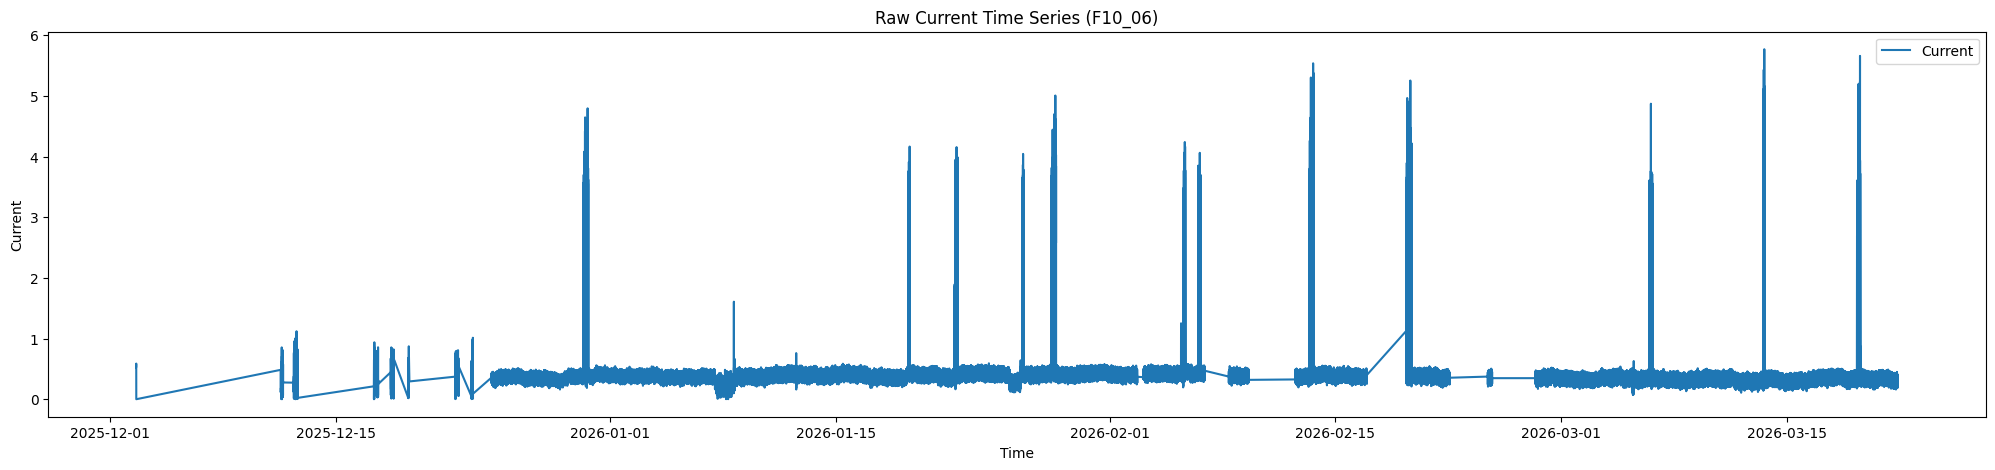

In [162]:
# ==========================================
# 1-1. 전체 데이터 시각화
# ==========================================

plt.figure(figsize=(25, 5))

plt.plot(df["s001"], df[COL], label="Current")

plt.title(f"Raw Current Time Series ({COL})")
plt.xlabel("Time")
plt.ylabel("Current")
plt.legend()

plt.show()

In [163]:
# ==========================================
# 2. 스케일링
# ==========================================

scaler = MinMaxScaler()
df["scaled"] = scaler.fit_transform(df[[COL]])

In [164]:
from lms_mon.extract_spike import extract_spike

SEQ_LEN = 20

all_sequences, indices = extract_spike(
            df["scaled"].values.reshape(-1),
            seq_len=SEQ_LEN,
            pre_offset=5,
            slope_factor=3.0,
            min_jump=0.3,
            dedup_gap=10,
        )

print("스파이크 개수:", len(all_sequences))
# print("발생 위치:", indices)

스파이크 개수: 1311


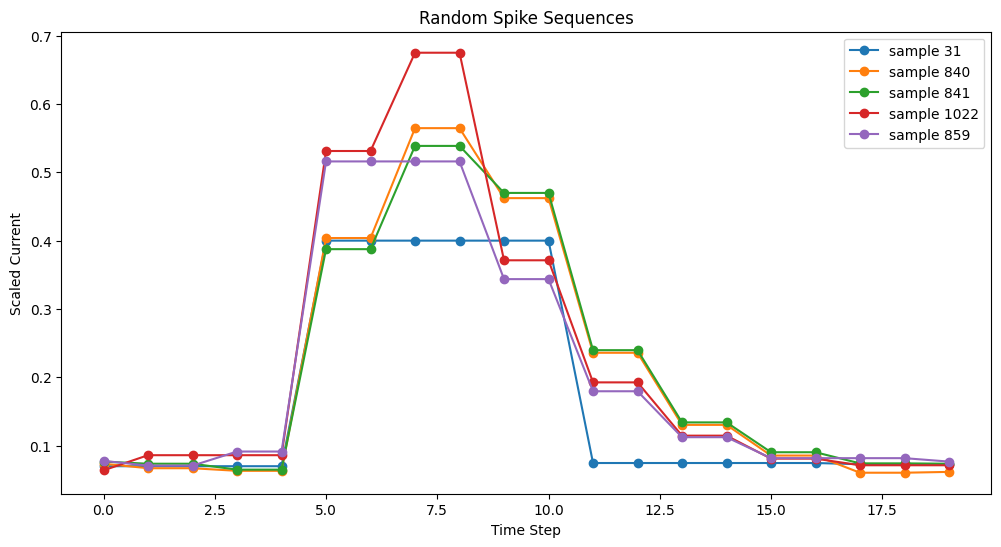

In [165]:
# ==========================================
# 3-1. 스파이크 전류 스케일 데이터 시각화
# ==========================================

def plot_random_sequences(sequences, num_samples=5):
    plt.figure(figsize=(12, 6))
    
    for i in range(num_samples):
        idx = random.randint(0, len(sequences)-1)
        seq = sequences[idx]
        
        plt.plot(seq, marker='o', label=f"sample {idx}")
    
    plt.title("Random Spike Sequences")
    plt.xlabel("Time Step")
    plt.ylabel("Scaled Current")
    plt.legend()
    plt.show()

plot_random_sequences(all_sequences, 5)

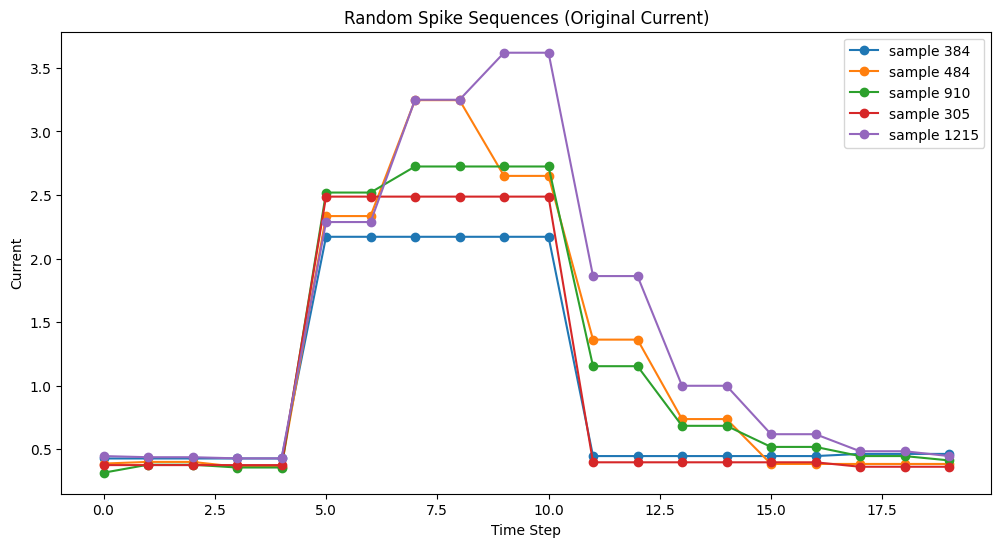

In [166]:
# ==========================================
# 3-2. 스파이크 전류 원본 데이터 시각화
# ==========================================

def plot_random_sequences_original(sequences, scaler, num_samples=5):
    plt.figure(figsize=(12, 6))
    
    for i in range(num_samples):
        idx = random.randint(0, len(sequences)-1)
        seq = sequences[idx]
        
        # 🔥 역정규화
        seq_original = scaler.inverse_transform(seq.reshape(-1, 1)).flatten()
        
        plt.plot(seq_original, marker='o', label=f"sample {idx}")
    
    plt.title("Random Spike Sequences (Original Current)")
    plt.xlabel("Time Step")
    plt.ylabel("Current")
    plt.legend()
    plt.show()

plot_random_sequences_original(all_sequences, scaler, 5)

In [167]:
# ==========================================
# 4. Train / Test 분리
# ==========================================

train_sequences, test_sequences = train_test_split(
    all_sequences,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(train_sequences.shape, test_sequences.shape)

(1048, 20) (263, 20)


In [168]:
# ==========================================
# 5. Tensor 변환
# ==========================================

BATCH_SIZE = 128

X_train = torch.tensor(train_sequences, dtype=torch.float32).unsqueeze(-1)
X_test = torch.tensor(test_sequences, dtype=torch.float32).unsqueeze(-1)

train_dataset = TensorDataset(X_train, X_train)
test_dataset = TensorDataset(X_test, X_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [169]:
# ==========================================
# 6. LSTM Autoencoder
# ==========================================

class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super().__init__()
        
        self.seq_len = seq_len
        
        self.encoder = nn.LSTM(
            n_features, embedding_dim,
            num_layers=2, batch_first=True, dropout=0.2
        )
        
        self.decoder = nn.LSTM(
            embedding_dim, embedding_dim,
            num_layers=2, batch_first=True, dropout=0.2
        )
        
        self.output_layer = nn.Linear(embedding_dim, n_features)
    
    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        hidden = hidden[-1]
        
        hidden = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        decoded, _ = self.decoder(hidden)
        out = torch.sigmoid(self.output_layer(decoded))
        
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAutoencoder(SEQ_LEN, 1).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [170]:
# ==========================================
# 7. 학습
# ==========================================

EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    losses = []
    
    for batch_x, _ in tqdm(train_loader):
        batch_x = batch_x.to(device)
        
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    print(f"Epoch {epoch+1} Loss:", np.mean(losses))

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 41.01it/s]


Epoch 1 Loss: 0.11386838224199083


100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 83.25it/s]


Epoch 2 Loss: 0.11063727156983481


100%|███████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 126.76it/s]


...

Epoch 98 Loss: 0.007843702514138486


100%|███████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 310.33it/s]


Epoch 99 Loss: 0.008019844846179089


100%|███████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 284.60it/s]

Epoch 100 Loss: 0.007931171192063225


In [171]:
# ==========================================
# 8. Threshold 계산
# ==========================================

def get_errors(model, loader):
    model.eval()
    errors = []
    
    with torch.no_grad():
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)
            output = model(batch_x)
            
            loss = torch.mean((batch_x - output) ** 2, dim=(1,2))
            errors.extend(loss.cpu().numpy())
    
    return np.array(errors)

train_errors = get_errors(model, train_loader)

threshold = np.percentile(train_errors, 99.5)

print("Threshold:", threshold)

Threshold: 0.04833099398762001


In [172]:
# ==========================================
# 9. 테스트 이상 탐지
# ==========================================

test_errors = get_errors(model, test_loader)

anomalies = test_errors > threshold

print("이상 개수:", np.sum(anomalies))

이상 개수: 1


In [173]:
anomaly_indices = np.where(anomalies)[0]
print("이상 인덱스:", anomaly_indices[:10])

이상 인덱스: [211]


In [174]:
signal_scaled = df["scaled"].values
signal_raw = df[COL].values

def find_sequence_index(signal_scaled, seq):
    for i in range(len(signal_scaled) - len(seq)):
        if np.allclose(signal_scaled[i:i+len(seq)], seq):
            return i
    return None

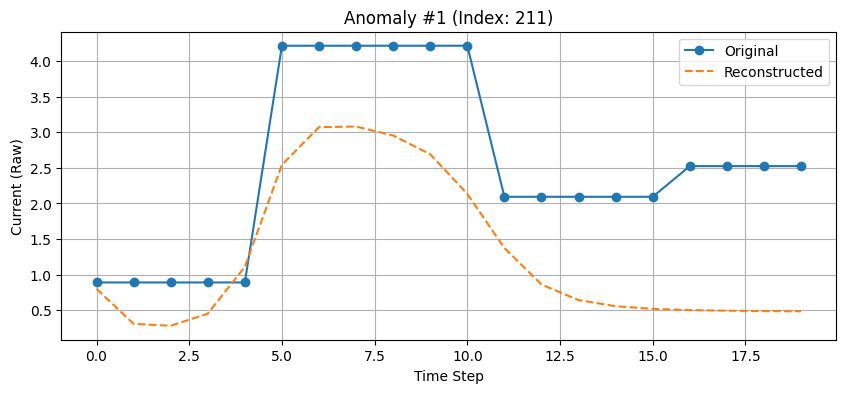

original: [0.89      0.89      0.89      0.89      0.89      4.2169995 4.2169995
 4.2169995 4.2169995 4.2169995 4.2169995 2.094     2.094     2.094
 2.094     2.094     2.525     2.525     2.525     2.525    ]
reconstructed: [0.8013205  0.3078349  0.28195867 0.45110357 1.1092902  2.543574
 3.0725026  3.0810862  2.9556181  2.6915877  2.134542   1.3736465
 0.8612945  0.6423583  0.5560804  0.51921624 0.50176644 0.49277624
 0.48780602 0.48492566]


In [175]:
def plot_anomaly_with_reconstruction(
    model,
    test_sequences,
    anomaly_indices,
    num_samples=5
):
    model.eval()
    
    if len(anomaly_indices) == 0:
        print("이상 없음")
        return
    
    selected = random.sample(
        list(anomaly_indices),
        min(num_samples, len(anomaly_indices))
    )
    
    for i, idx in enumerate(selected):
        seq_scaled = test_sequences[idx]
        
        # 🔥 모델 입력
        input_tensor = torch.tensor(seq_scaled, dtype=torch.float32)\
            .unsqueeze(0).unsqueeze(-1).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
        
        # 🔥 numpy 변환
        input_seq = input_tensor.squeeze().cpu().numpy()
        output_seq = output.squeeze().cpu().numpy()
        
        # 🔥 원본 전류로 복원
        input_raw = scaler.inverse_transform(input_seq.reshape(-1,1)).flatten()
        output_raw = scaler.inverse_transform(output_seq.reshape(-1,1)).flatten()
        
        # 🔥 👉 그래프를 매번 새로 생성
        plt.figure(figsize=(10, 4))
        
        plt.plot(input_raw, marker='o', label="Original")
        plt.plot(output_raw, linestyle='--', label="Reconstructed")
        
        plt.title(f"Anomaly #{i+1} (Index: {idx})")
        plt.xlabel("Time Step")
        plt.ylabel("Current (Raw)")
        plt.legend()
        plt.grid(True)
        
        plt.show()

        print(f'original: {input_raw}')
        print(f'reconstructed: {output_raw}')

plot_anomaly_with_reconstruction(model, test_sequences, anomaly_indices, num_samples=10)

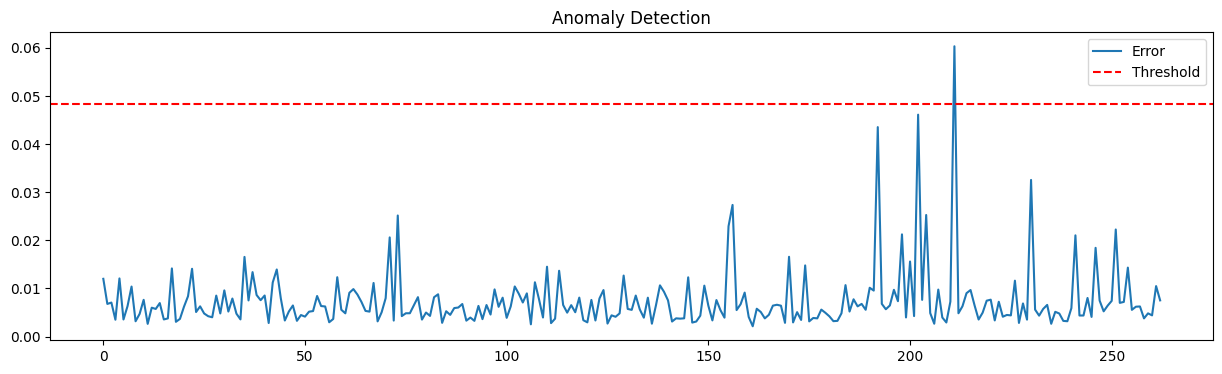

In [176]:
# ==========================================
# 10. 시각화
# ==========================================

plt.figure(figsize=(15,4))
plt.plot(test_errors, label="Error")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")
plt.legend()
plt.title("Anomaly Detection")
plt.show()

In [177]:
SAVE_DIR = f"./model/{COL}"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. 모델 저장
torch.save(model.state_dict(), f"{SAVE_DIR}/model.pth")

# 2. 스케일러 저장
joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")

# 3. threshold 저장
np.save(f"{SAVE_DIR}/threshold.npy", threshold)

print(f"모델 저장 완료 → {SAVE_DIR}")

모델 저장 완료 → ./model/F10_06
